# Importing libraries

In [328]:
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import os
import fiona
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

# Loading data sets

In [329]:
#Load prescreened MSR shapes (with LCOE and CAPEX values defined) 
S3_MSR_pv_file = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_TandR_costs\SolarPV_prescreen.shp'
S3_MSR_wind_file = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_TandR_costs\Wind_prescreen.shp'

In [330]:
gdf3wind = gpd.read_file(S3_MSR_wind_file)
gdf3solar = gpd.read_file(S3_MSR_pv_file)

In [331]:
gdf3wind.head(2)

,FID,AreakM2,CapacityMW,RoadDist,T_Dist_gf,D_Dist_gf,TD_Dist_gf,SubstnDist,Load_dst,City_name,...,sLCOE-MWh,sCAPEX-kW,tLCOE-MWh,tCAPEX-kW,rLCOE-MWh,rCAPEX-kW,LCOE-MWh,trCAPEX-kW,TotalCAPEX,geometry
0,0,152.806260,449.250405,1.201183,4.121323,2.393051,2.393051,8.756527,21.379872,Montero,...,46.725910,155.006478,2.174889,8.556327,1.195218,4.702160,50.096017,13.258487,168.264965,"POLYGON ((-6170447.880 -2147198.864, -6170147...."
1,1,209.618699,616.278976,1.244803,3.557781,2.410556,2.410556,13.902395,15.999640,Santa Cruz1,...,45.184119,155.006478,2.076651,8.448621,1.197751,4.872913,48.458521,13.321534,168.328012,"POLYGON ((-6169846.689 -2164332.817, -6169546...."


In [332]:
def generate_supply_curve(geo_dataframe,ranking_col,accumulation_col,ascending=True,):
    """
    Creates a supply curve by sorting a dataframe (geo_dataframe) based on [ranking_col] and 
    accumulating values based on [accumulation_col], using matplotlib.
    """

    # Copy to avoid altering original
    df = geo_dataframe[[ranking_col, accumulation_col]].copy()

    # Sort by chosen metric
    df = df.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)

    # Create cumulative sum
    df["cumulative"] = df[accumulation_col].cumsum()

    # Matplotlib figure
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(df["cumulative"], df[ranking_col], marker='o', linestyle='-')
    
    ax.set_title(f"Supply Curve: {ranking_col} vs cumulative {accumulation_col}")
    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(f"{ranking_col}")

    ax.grid(True)
    
    plt.show()
    
    return df

# Check of potential fitting curve types

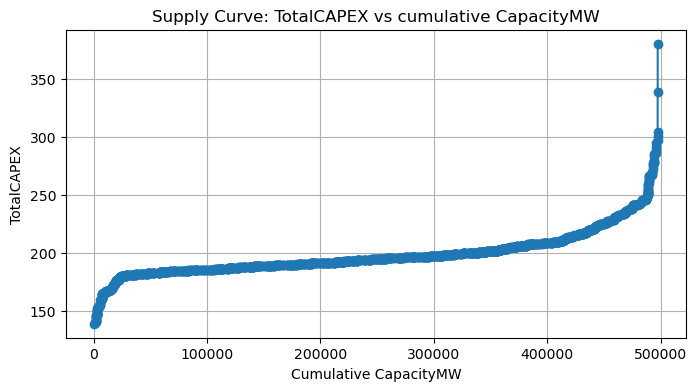

In [372]:
df = generate_supply_curve(geo_dataframe=gdf3wind,ranking_col="TotalCAPEX",accumulation_col="CapacityMW",ascending=True)

In [334]:
capacity = df["cumulative"].values      # accumulated capacity
capex = df["TotalCAPEX"].values            # USD/MW (annualized) 

In [335]:
print(df.describe())
print(df.isna().sum())

        TotalCAPEX   CapacityMW     cumulative
count  1412.000000  1412.000000    1412.000000
mean    200.670526   352.301319  267177.113916
std      22.908549   520.767400  153524.420907
min     139.012914    20.189537     363.610905
25%     187.566399    33.937018  130083.890178
50%     196.971345    82.059842  295430.229185
75%     209.362448   463.341019  406944.173450
max     380.506737  2665.018885  497449.462176
TotalCAPEX    0
CapacityMW    0
cumulative    0
dtype: int64


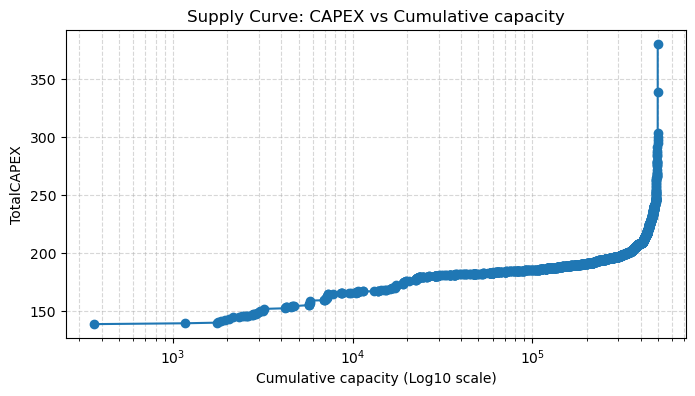

In [373]:
# Matplotlib figure
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df["cumulative"], df["TotalCAPEX"], marker='o', linestyle='-')


ax.set_xscale('log')
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0))

ax.set_title(f"Supply Curve: CAPEX vs Cumulative capacity")
ax.set_xlabel(f"Cumulative capacity (Log10 scale)")
ax.set_ylabel(f"TotalCAPEX")

ax.grid(True, which="both", linestyle="--", alpha=0.5)
    
plt.show()

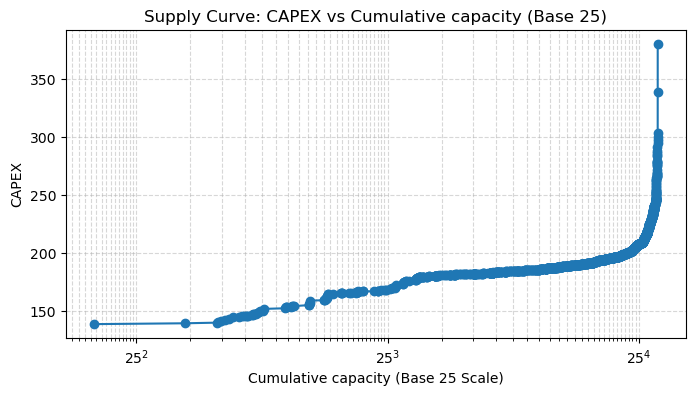

In [363]:
fig, ax = plt.subplots(figsize=(8, 4))

# 1. Plot the RAW data (no np.log needed)
ax.plot(df["cumulative"], df["TotalCAPEX"], marker='o', linestyle='-')
    
# 2. Set the x-scale to log, but force the base to 25
ax.set_xscale('log', base=25)

# 3. Explicitly tell Matplotlib to place major ticks at powers of 25
ax.xaxis.set_major_locator(ticker.LogLocator(base=25.0))

ax.set_title("Supply Curve: CAPEX vs Cumulative capacity (Base 25)")
ax.set_xlabel("Cumulative capacity (Base 25 Scale)")
ax.set_ylabel("CAPEX")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
    
plt.show()

# Trim extreme capex values based on 99% of accumulated capcity 

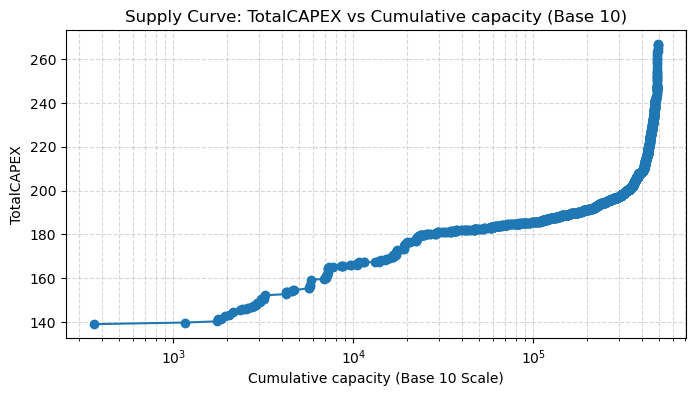

In [338]:
# secondary option to trim the last point is to set it to NaN (using % instead of just removing 1 point)
q_cut = 0.99 * capacity.max()

mask = capacity <= q_cut

capacity_fit = capacity[mask]
capex_fit = capex[mask]


fig, ax = plt.subplots(figsize=(8, 4))

# 1. Plot the RAW data (no np.log needed)
ax.plot(capacity_fit, capex_fit, marker='o', linestyle='-')
    
# 2. Set the x-scale to log, but force the base to 10
ax.set_xscale('log', base=10)

# 3. Explicitly tell Matplotlib to place major ticks at powers of 10
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0))

ax.set_title("Supply Curve: TotalCAPEX vs Cumulative capacity (Base 10)")
ax.set_xlabel("Cumulative capacity (Base 10 Scale)")
ax.set_ylabel("TotalCAPEX")
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# Testing convexity with first differences

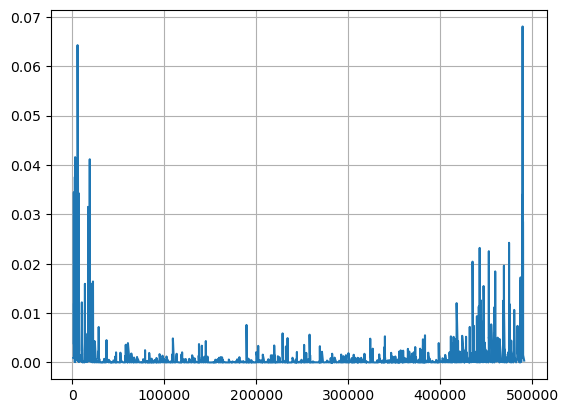

In [339]:
dQ = np.diff(capacity_fit)
dcapex = np.diff(capex_fit)

ratio = dcapex / dQ

plt.plot(capacity_fit[1:], ratio)
#plt.yscale('log')  # likely useful
plt.grid()

All values are positive which indicates convexity on the surface under the marginal investment (capex) curve in the cost-supply curve 
Change ratio (delta lcoe/delta capacity) seems to change at around 30k (it stabilizes) and also after 350k 

# Testing linear piecewise funtions (based on N number of bins) with courve_fit function (minimizes the variance of the entire piecewise fucntion)

## Piecewise formualtion for N=3 bins

In [340]:
import numpy as np
from scipy.optimize import curve_fit

def all_linear_piecewise(x, knot1, knot2, m1, c1, m2, m3):
    y = np.zeros_like(x, dtype=float)
    
    # --- REGION 1: The Beginning (Linear) ---
    mask1 = x < knot1
    y[mask1] = m1 * x[mask1] + c1
    
    # Calculate connection height at knot1
    y1_at_knot1 = m1 * knot1 + c1
    
    # --- REGION 2: The Middle (Linear) ---
    mask2 = (x >= knot1) & (x < knot2)
    y[mask2] = m2 * (x[mask2] - knot1) + y1_at_knot1
    
    # Calculate connection height at knot2
    y2_at_knot2 = m2 * (knot2 - knot1) + y1_at_knot1
    
    # --- REGION 3: The End (Linear) ---
    mask3 = x >= knot2
    y[mask3] = m3 * (x[mask3] - knot2) + y2_at_knot2
    
    return y

# Initial guesses for: [knot1, knot2, m1, c1, m2, m3]
# Note: Because the beginning is steep, m1 needs a larger initial guess than m2.
initial_guesses = [30000, 370000, 0.0007, 35.0, 0.00009, 0.0003]

# Set bounds for the knots just like before
lower_bounds = [10000, 300000, -np.inf, -np.inf, -np.inf, -np.inf]
upper_bounds = [100000, 450000, np.inf, np.inf, np.inf, np.inf]

popt, _ = curve_fit(
    all_linear_piecewise, 
    capacity_fit, 
    capex_fit,  
    p0=initial_guesses, 
    bounds=(lower_bounds, upper_bounds)
)

In [341]:
# Unpack the optimized linear parameters
knot1, knot2, m1, c1, m2, m3 = popt

print("--- OPTIMIZED LINEAR COEFFICIENTS ---")
print(f"Knot 1 (First split):  {knot1:,.2f}")
print(f"Knot 2 (Second split): {knot2:,.2f}")
print(f"m1 (Beginning slope):  {m1:.8f}")
print(f"c1 (Initial Y-intercept): {c1:.6f}")
print(f"m2 (Middle slope):     {m2:.8f}")
print(f"m3 (End slope):        {m3:.8f}")
print("-------------------------------------")

--- OPTIMIZED LINEAR COEFFICIENTS ---
Knot 1 (First split):  20,703.48
Knot 2 (Second split): 409,800.44
m1 (Beginning slope):  0.00165204
c1 (Initial Y-intercept): 145.445686
m2 (Middle slope):     0.00006886
m3 (End slope):        0.00052967
-------------------------------------


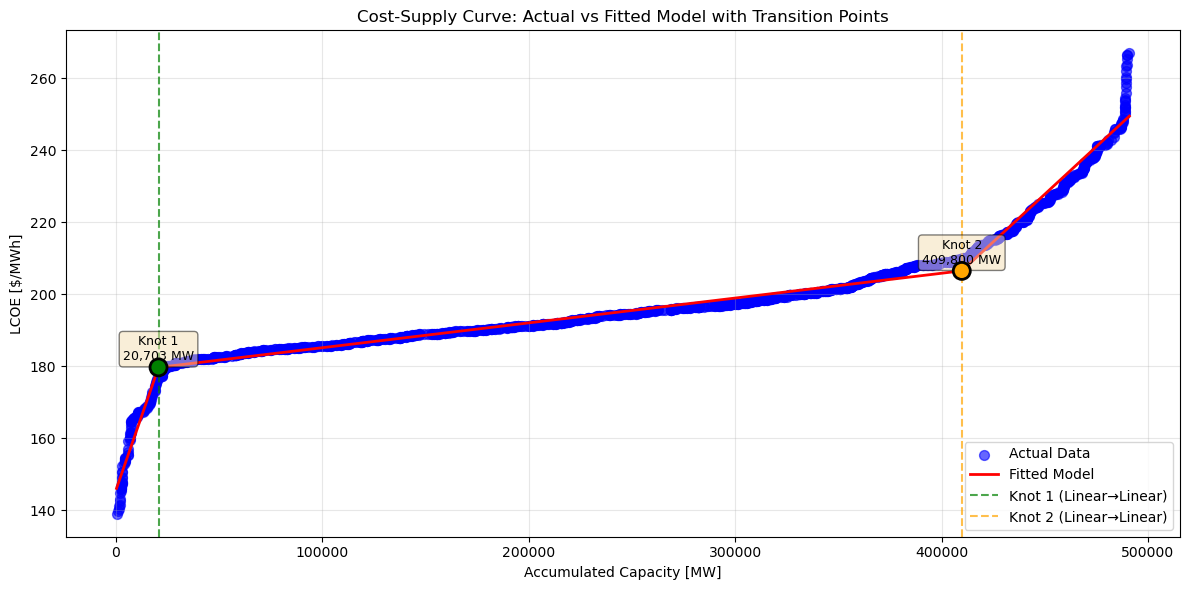

In [342]:
# Generate predicted LCOE values using the optimized parameters
lcoe_predicted = all_linear_piecewise(capacity_fit, knot1, knot2, m1, c1, m2, m3)

# Calculate LCOE values at the knots
lcoe_at_knot1 = all_linear_piecewise(np.array([knot1]), knot1, knot2, m1, c1, m2, m3)[0]
lcoe_at_knot2 = all_linear_piecewise(np.array([knot2]), knot1, knot2, m1, c1, m2, m3)[0]

# Create the overlay plot
plt.figure(figsize=(12, 6))

# Plot actual data points
plt.scatter(capacity_fit, capex_fit, color='blue', label='Actual Data', alpha=0.6, s=50)

# Plot the fitted curve
plt.plot(capacity_fit, lcoe_predicted, color='red', linewidth=2, label='Fitted Model')

# Highlight the knots
plt.axvline(x=knot1, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Knot 1 (Linear→Linear)')
plt.axvline(x=knot2, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Knot 2 (Linear→Linear)')

# Mark the knot points on the curve
plt.scatter([knot1, knot2], [lcoe_at_knot1, lcoe_at_knot2], 
            color=['green', 'orange'], s=150, marker='o', edgecolors='black', linewidth=2, zorder=5)

# Add text annotations for the knots
plt.text(knot1, lcoe_at_knot1 + 2, f'Knot 1\n{knot1:,.0f} MW', 
         ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(knot2, lcoe_at_knot2 + 2, f'Knot 2\n{knot2:,.0f} MW', 
         ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.xlabel("Accumulated Capacity [MW]")
plt.ylabel("LCOE [$/MWh]")
plt.title("Cost-Supply Curve: Actual vs Fitted Model with Transition Points")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Testing generalizable piecewise formualtion for N bins

In [343]:
import numpy as np
from scipy.optimize import curve_fit

def make_piecewise_linear(N):
    """
    Factory function that returns a piecewise linear function with N segments.
    
    Parameters:
      N : number of linear segments (bins)
    
    The parameter vector is structured as:
      [knot_1, knot_2, ..., knot_{N-1},   <- N-1 knots
       m_1, m_2, ..., m_N,                <- N slopes
       c_1]                               <- 1 intercept (first segment only)
    Total: (N-1) + N + 1 = 2N parameters
    """
    def piecewise_linear(x, *params):
        knots = np.array(params[:N-1])           # N-1 knot positions
        slopes = np.array(params[N-1:2*N-1])     # N slopes
        c1 = params[2*N-1]                       # intercept of first segment

        y = np.zeros_like(x, dtype=float)

        # Precompute the y-value at each knot (continuity constraints)
        # y_at_knot[i] = height at the end of segment i = start of segment i+1
        y_at_knots = np.zeros(N-1)
        y_at_knots[0] = slopes[0] * knots[0] + c1
        for i in range(1, N-1):
            y_at_knots[i] = slopes[i] * (knots[i] - knots[i-1]) + y_at_knots[i-1]

        # --- Segment 1: x < knot_1 ---
        mask = x < knots[0]
        y[mask] = slopes[0] * x[mask] + c1

        # --- Segments 2 to N-1: knot_{i-1} <= x < knot_i ---
        for i in range(1, N-1):
            mask = (x >= knots[i-1]) & (x < knots[i])
            y[mask] = slopes[i] * (x[mask] - knots[i-1]) + y_at_knots[i-1]

        # --- Segment N (last): x >= knot_{N-1} ---
        mask = x >= knots[-1]
        y[mask] = slopes[-1] * (x[mask] - knots[-1]) + y_at_knots[-1]

        return y

    piecewise_linear.__name__ = f"piecewise_linear_N{N}"
    return piecewise_linear


def fit_piecewise_linear(x_data, y_data, N,
                         knot_guesses=None,
                         knot_bounds=None,
                         slope_guesses=None,
                         intercept_guess=None):
    """
    Fit a piecewise linear function with N segments to data.

    Parameters
    ----------
    x_data, y_data   : array-like, the data to fit
    N                : int, number of segments
    knot_guesses     : list of N-1 initial knot positions
                       (default: evenly spaced in x range)
    knot_bounds      : list of N-1 (lo, hi) tuples for each knot
                       (default: full x range for each)
    slope_guesses    : list of N initial slope guesses
                       (default: global slope for all)
    intercept_guess  : float, initial intercept for first segment
                       (default: y_data[0])

    Returns
    -------
    popt   : fitted parameters [knots..., slopes..., intercept]
    fn     : the fitted piecewise function (callable)
    knots  : fitted knot positions
    slopes : fitted slopes per segment
    c1     : fitted intercept
    """
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    # --- Build default initial guesses ---
    x_min, x_max = x_data.min(), x_data.max()
    y_min, y_max = y_data.min(), y_data.max()
    global_slope = (y_max - y_min) / (x_max - x_min)

    if knot_guesses is None:
        knot_guesses = list(np.linspace(x_min, x_max, N+1)[1:-1])  # N-1 interior knots

    if slope_guesses is None:
        slope_guesses = [global_slope] * N

    if intercept_guess is None:
        intercept_guess = float(y_data[0])

    p0 = knot_guesses + slope_guesses + [intercept_guess]

    # --- Build bounds ---
    if knot_bounds is None:
        knot_lower = [x_min] * (N-1)
        knot_upper = [x_max] * (N-1)
    else:
        knot_lower = [b[0] for b in knot_bounds]
        knot_upper = [b[1] for b in knot_bounds]

    # Slopes and intercept are unconstrained
    lower_bounds = knot_lower + [-np.inf] * N + [-np.inf]
    upper_bounds = knot_upper + [ np.inf] * N + [ np.inf]

    fn = make_piecewise_linear(N)
    popt, pcov = curve_fit(fn, x_data, y_data,
                           p0=p0,
                           bounds=(lower_bounds, upper_bounds))

    knots  = list(popt[:N-1])
    slopes = list(popt[N-1:2*N-1])
    c1     = popt[2*N-1]

    return popt, fn, knots, slopes, c1

In [344]:
def plot_piecewise_fit(x_data, y_data, fn, knots, slopes, c1, popt,
                       x_label="log10 (Accumulated Capacity [MW])",
                       y_label="CAPEX [$/MW]",
                       title="Cost-Supply Curve: Actual vs Fitted Model"):
    
    N = len(slopes)
    
    # --- Evaluate fitted curve and knot heights ---
    y_predicted = fn(x_data, *popt)
    y_at_knots  = [fn(np.array([k]), *popt)[0] for k in knots]

    # --- Colors for knots (cycles if N is large) ---
    knot_colors = plt.cm.tab10(np.linspace(0, 0.9, len(knots)))

    # --- Plot ---
    plt.figure(figsize=(12, 6))

    plt.scatter(x_data, y_data, color='blue', label='Actual Data', alpha=0.6, s=50)
    plt.plot(x_data, y_predicted, color='red', linewidth=2, label='Fitted Model')

    for i, (k, yk, color) in enumerate(zip(knots, y_at_knots, knot_colors)):
        plt.axvline(x=k, color=color, linestyle='--', linewidth=1.5, alpha=0.7,
                    label=f'Knot {i+1}')
        plt.scatter([k], [yk], color=[color], s=150, marker='o',
                    edgecolors='black', linewidth=2, zorder=5)
        plt.text(k, yk + 0.02 * (y_data.max() - y_data.min()),
                 f'Knot {i+1}\n{10**k:,.0f} MW',
                 ha='center', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Print summary ---
    print("--- OPTIMIZED LINEAR COEFFICIENTS ---")
    print(f"  Intercept c1: {c1:.6f}")
    for i, k in enumerate(knots):
        print(f"  Knot {i+1}: {k:,.2f} MW")
    for i, m in enumerate(slopes):
        print(f"  Slope m{i+1}: {m:.8f}")
    print("-------------------------------------")

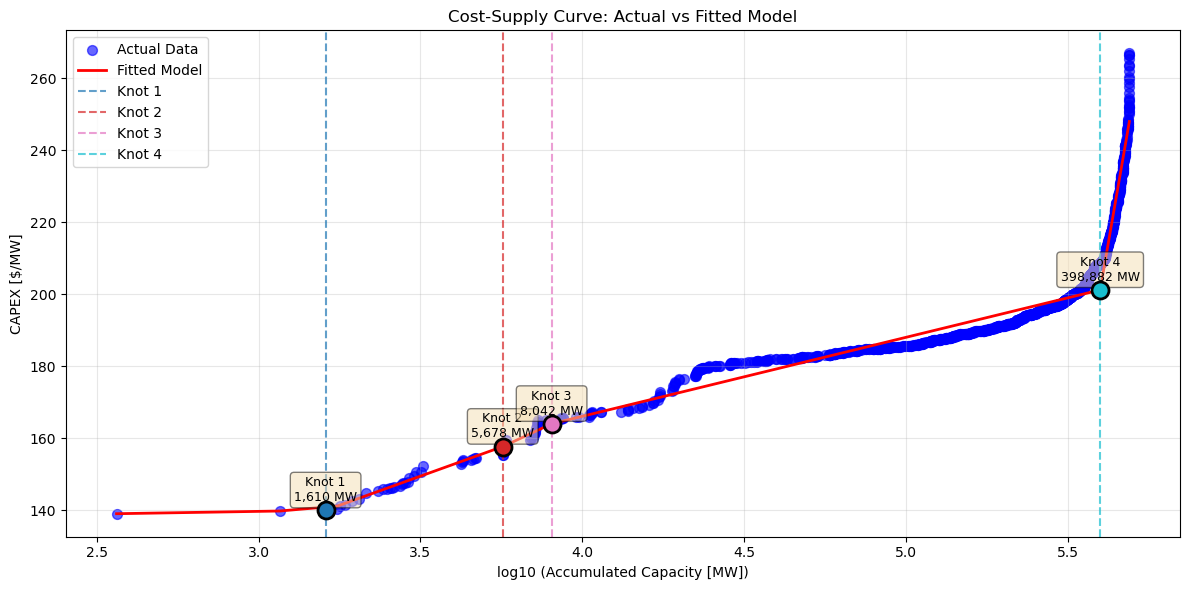

--- OPTIMIZED LINEAR COEFFICIENTS ---
  Intercept c1: 135.217005
  Knot 1: 3.21 MW
  Knot 2: 3.75 MW
  Knot 3: 3.91 MW
  Knot 4: 5.60 MW
  Slope m1: 1.47709939
  Slope m2: 32.29235107
  Slope m3: 41.95973986
  Slope m4: 21.92656481
  Slope m5: 518.56787965
-------------------------------------


In [345]:
popt, fn, knots, slopes, c1 = fit_piecewise_linear(np.log10(capacity_fit), capex_fit, N=5)

plot_piecewise_fit(np.log10(capacity_fit), capex_fit, fn, knots, slopes, c1, popt)

In [346]:
knots_alt = 10**np.array(knots)
knots_alt

array([  1610.17751649,   5677.91583687,   8042.14969757, 398882.37705866])

In [347]:
def plot_piecewise_fit2(x_data, y_data, fn, knots, slopes, c1, popt,
                       x_label="Accumulated Capacity [MW]",
                       y_label="CAPEX [$/MW]",
                       title="Cost-Supply Curve: Actual vs Fitted Model"):
    
    N = len(slopes)
    
    # --- Evaluate fitted curve and knot heights ---
    y_predicted = fn(x_data, *popt)
    y_at_knots  = [fn(np.array([k]), *popt)[0] for k in knots]

    # --- Colors for knots (cycles if N is large) ---
    knot_colors = plt.cm.tab10(np.linspace(0, 0.9, len(knots)))

    # --- Plot ---
    plt.figure(figsize=(12, 6))

    plt.scatter(x_data, y_data, color='blue', label='Actual Data', alpha=0.6, s=50)
    plt.plot(x_data, y_predicted, color='red', linewidth=2, label='Fitted Model')

    for i, (k, yk, color) in enumerate(zip(knots, y_at_knots, knot_colors)):
        plt.axvline(x=k, color=color, linestyle='--', linewidth=1.5, alpha=0.7,
                    label=f'Knot {i+1}')
        plt.scatter([k], [yk], color=[color], s=150, marker='o',
                    edgecolors='black', linewidth=2, zorder=5)
        plt.text(k, yk + 0.02 * (y_data.max() - y_data.min()),
                 f'Knot {i+1}\n{k:,.0f} MW',
                 ha='center', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Print summary ---
    print("--- OPTIMIZED LINEAR COEFFICIENTS ---")
    print(f"  Intercept c1: {c1:.6f}")
    for i, k in enumerate(knots):
        print(f"  Knot {i+1}: {k:,.2f} MW")
    for i, m in enumerate(slopes):
        print(f"  Slope m{i+1}: {m:.8f}")
    print("-------------------------------------")

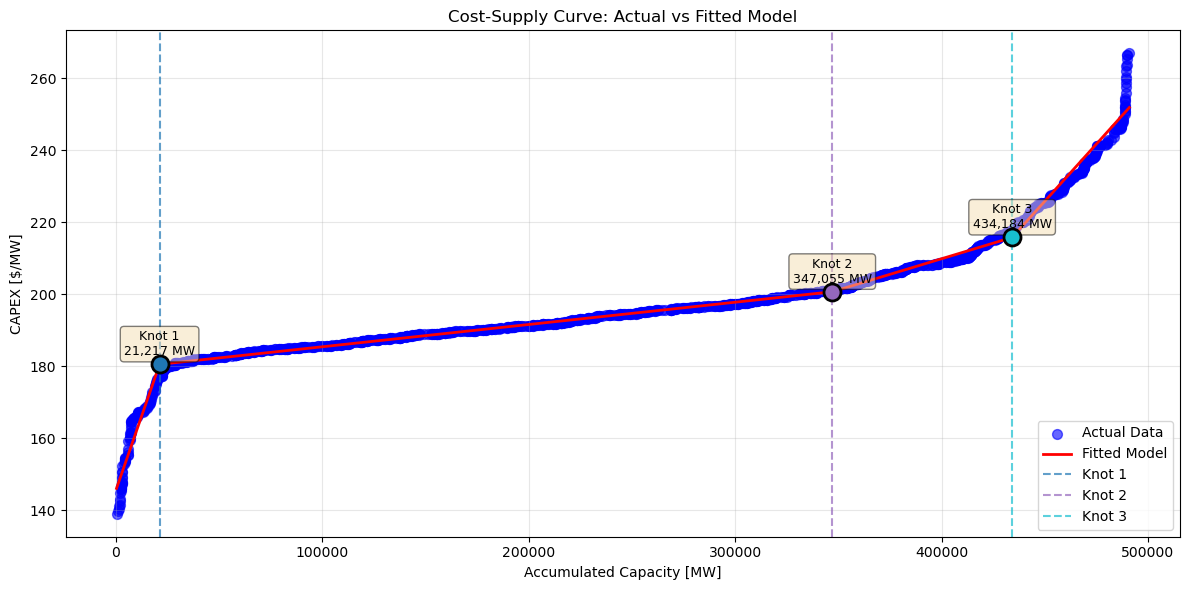

--- OPTIMIZED LINEAR COEFFICIENTS ---
  Intercept c1: 145.445686
  Knot 1: 21,216.86 MW
  Knot 2: 347,055.14 MW
  Knot 3: 434,184.27 MW
  Slope m1: 0.00165204
  Slope m2: 0.00006183
  Slope m3: 0.00017324
  Slope m4: 0.00063527
-------------------------------------


In [348]:
popt, fn, knots, slopes, c1 = fit_piecewise_linear((capacity_fit), capex_fit, N=4)

plot_piecewise_fit2((capacity_fit), capex_fit, fn, knots, slopes, c1, popt)

## Testing piecewise formulation based on homogeneous bins (Size = Accumulated capacity / N bins)

In [349]:
def make_piecewise_linear_homogeneous(N, knots):
    """
    Factory function that returns a piecewise linear function with N segments
    and fixed (homogeneous) knots.
    
    Parameters:
      N : number of linear segments (bins)
      knots : list of N-1 knot positions (pre-calculated, fixed)
    
    The parameter vector is structured as:
      [m_1, m_2, ..., m_N,                <- N slopes
       c_1]                               <- 1 intercept (first segment only)
    Total: N + 1 parameters (knots are fixed, not fitted)
    """
    knots = np.array(knots)
    
    def piecewise_linear(x, *params):
        slopes = np.array(params[:N])      # N slopes
        c1 = params[N]                     # intercept of first segment

        y = np.zeros_like(x, dtype=float)

        # Precompute the y-value at each knot (continuity constraints)
        y_at_knots = np.zeros(N-1)
        y_at_knots[0] = slopes[0] * knots[0] + c1
        for i in range(1, N-1):
            y_at_knots[i] = slopes[i] * (knots[i] - knots[i-1]) + y_at_knots[i-1]

        # --- Segment 1: x < knot_1 ---
        mask = x < knots[0]
        y[mask] = slopes[0] * x[mask] + c1

        # --- Segments 2 to N-1: knot_{i-1} <= x < knot_i ---
        for i in range(1, N-1):
            mask = (x >= knots[i-1]) & (x < knots[i])
            y[mask] = slopes[i] * (x[mask] - knots[i-1]) + y_at_knots[i-1]

        # --- Segment N (last): x >= knot_{N-1} ---
        mask = x >= knots[-1]
        y[mask] = slopes[-1] * (x[mask] - knots[-1]) + y_at_knots[-1]

        return y

    piecewise_linear.__name__ = f"piecewise_linear_homogeneous_N{N}"
    return piecewise_linear


def fit_piecewise_linear_homogeneous(x_data, y_data, N,
                                     slope_guesses=None,
                                     intercept_guess=None):
    """
    Fit a piecewise linear function with N segments to data using homogeneous 
    (evenly-spaced) knot positions based on accumulated capacity / N bins.

    Parameters
    ----------
    x_data, y_data   : array-like, the data to fit
    N                : int, number of segments (bins)
    slope_guesses    : list of N initial slope guesses
                       (default: global slope for all)
    intercept_guess  : float, initial intercept for first segment
                       (default: y_data[0])

    Returns
    -------
    popt   : fitted parameters [slopes..., intercept]
    fn     : the fitted piecewise function (callable)
    knots  : knot positions (fixed, homogeneously spaced)
    slopes : fitted slopes per segment
    c1     : fitted intercept
    """
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    # --- Calculate homogeneous knots internally ---
    x_min, x_max = x_data.min(), x_data.max()
    knots = list(np.linspace(x_min, x_max, N+1)[1:-1])  # N-1 evenly-spaced knots

    # --- Build default initial guesses for slopes and intercept ---
    y_min, y_max = y_data.min(), y_data.max()
    global_slope = (y_max - y_min) / (x_max - x_min)

    if slope_guesses is None:
        slope_guesses = [global_slope] * N

    if intercept_guess is None:
        intercept_guess = float(y_data[0])

    p0 = slope_guesses + [intercept_guess]

    # No bounds on slopes and intercept (unconstrained)
    lower_bounds = [-np.inf] * N + [-np.inf]
    upper_bounds = [ np.inf] * N + [ np.inf]

    fn = make_piecewise_linear_homogeneous(N, knots)
    popt, pcov = curve_fit(fn, x_data, y_data,
                           p0=p0,
                           bounds=(lower_bounds, upper_bounds))

    slopes = list(popt[:N])
    c1     = popt[N]

    return popt, fn, knots, slopes, c1

def plot_piecewise_fit_homogeneous(x_data, y_data, fn, knots, slopes, c1, popt,
                       x_label="log10 (Accumulated Capacity [MW])",
                       y_label="CAPEX [$/MW]",
                       title="Cost-Supply Curve: Actual vs Fitted Model"):
    
    N = len(slopes)
    
    # --- Evaluate fitted curve and knot heights ---
    y_predicted = fn(x_data, *popt)
    y_at_knots  = [fn(np.array([k]), *popt)[0] for k in knots]

    # --- Colors for knots (cycles if N is large) ---
    knot_colors = plt.cm.tab10(np.linspace(0, 0.9, len(knots)))

    # --- Plot ---
    plt.figure(figsize=(12, 6))

    plt.scatter(x_data, y_data, color='blue', label='Actual Data', alpha=0.6, s=50)
    plt.plot(x_data, y_predicted, color='red', linewidth=2, label='Fitted Model')

    for i, (k, yk, color) in enumerate(zip(knots, y_at_knots, knot_colors)):
        plt.axvline(x=k, color=color, linestyle='--', linewidth=1.5, alpha=0.7,
                    label=f'Knot {i+1}')
        plt.scatter([k], [yk], color=[color], s=150, marker='o',
                    edgecolors='black', linewidth=2, zorder=5)
        plt.text(k, yk + 0.02 * (y_data.max() - y_data.min()),
                 f'Knot {i+1}\n{10**k:,.0f} MW',
                 ha='center', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Print summary ---
    print("--- OPTIMIZED LINEAR COEFFICIENTS ---")
    print(f"  Intercept c1: {c1:.6f}")
    for i, k in enumerate(knots):
        print(f"  Knot {i+1}: {k:,.2f}")
    for i, m in enumerate(slopes):
        print(f"  Slope m{i+1}: {m:.8f}")
    print("-------------------------------------")

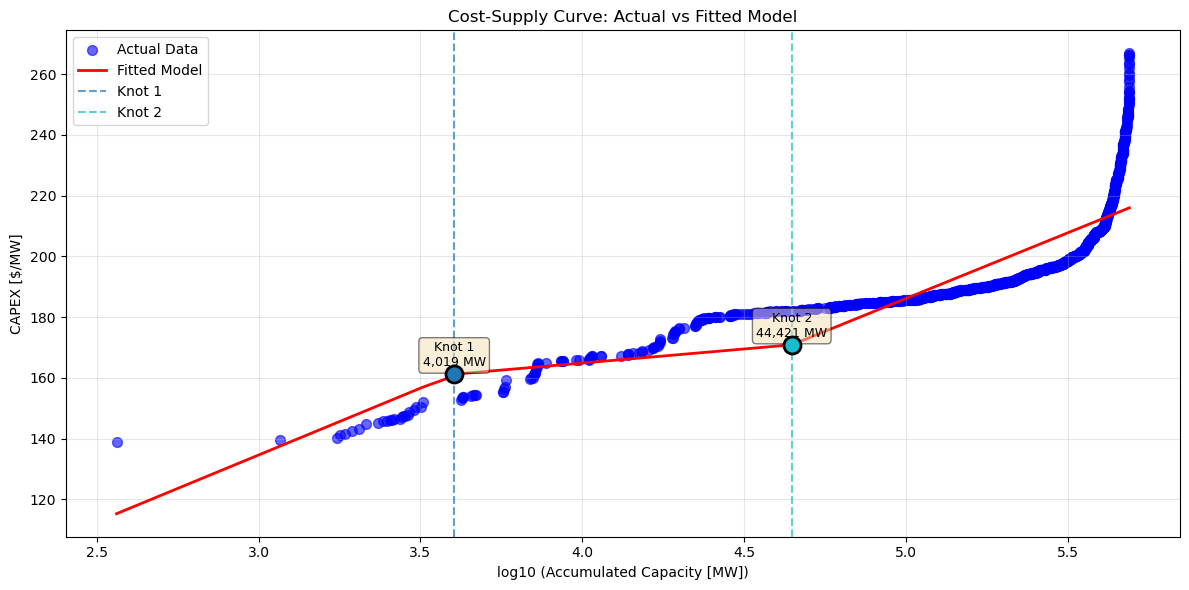

--- OPTIMIZED LINEAR COEFFICIENTS ---
  Intercept c1: 2.640050
  Knot 1: 3.60 MW
  Knot 2: 4.65 MW
  Slope m1: 44.00607366
  Slope m2: 9.27355079
  Slope m3: 43.21466722
-------------------------------------


In [350]:
popt, fn, knots, slopes, c1 = fit_piecewise_linear_homogeneous(np.log10(capacity_fit), capex_fit, N=3)
plot_piecewise_fit(np.log10(capacity_fit), capex_fit, fn, knots, slopes, c1, popt)

## Testing piecewise formulation based on given N-1 knots based on N bins

In [351]:
total_range = capacity_fit.max() - capacity_fit.min()
bins = 3

log_min = np.log10(capacity_fit.min())
log_max = np.log10(capacity_fit.max())
range_log = (log_max - log_min) / bins

knots_10 = [log_min + (i + 1) * range_log for i in range(bins - 1)]
knots = 10 ** np.array(knots_10)
print (knots_10)
print (knots)

[3.6041111853367465, 4.64758547107756]
[ 4018.93687969 44420.70746834]


In [352]:
def make_piecewise_linear_given(N, knots):
    """
    Factory function that returns a piecewise linear function with N segments
    and fixed (homogeneous) knots.
    
    Parameters:
      N : number of linear segments (bins)
      knots : list of N-1 knot positions (pre-calculated, fixed)
    
    The parameter vector is structured as:
      [m_1, m_2, ..., m_N,                <- N slopes
       c_1]                               <- 1 intercept (first segment only)
    Total: N + 1 parameters (knots are fixed, not fitted)
    """
    knots = np.array(knots)
    
    def piecewise_linear(x, *params):
        slopes = np.array(params[:N])      # N slopes
        c1 = params[N]                     # intercept of first segment

        y = np.zeros_like(x, dtype=float)

        # Precompute the y-value at each knot (continuity constraints)
        y_at_knots = np.zeros(N-1)
        y_at_knots[0] = slopes[0] * knots[0] + c1
        for i in range(1, N-1):
            y_at_knots[i] = slopes[i] * (knots[i] - knots[i-1]) + y_at_knots[i-1]

        # --- Segment 1: x < knot_1 ---
        mask = x < knots[0]
        y[mask] = slopes[0] * x[mask] + c1

        # --- Segments 2 to N-1: knot_{i-1} <= x < knot_i ---
        for i in range(1, N-1):
            mask = (x >= knots[i-1]) & (x < knots[i])
            y[mask] = slopes[i] * (x[mask] - knots[i-1]) + y_at_knots[i-1]

        # --- Segment N (last): x >= knot_{N-1} ---
        mask = x >= knots[-1]
        y[mask] = slopes[-1] * (x[mask] - knots[-1]) + y_at_knots[-1]

        return y

    piecewise_linear.__name__ = f"piecewise_linear_given_N{N}"
    return piecewise_linear


def fit_piecewise_linear_given(
        x_data,
        y_data,
        N,
        knots=None,
        slope_guesses=None,
        intercept_guess=None,
        knot_method="log"
):
    """
    Parameters
    ----------
    N : int
        Number of segments.
    knots : list or None
        Fixed knot positions. If None, they are generated automatically.
    knot_method : {"log", "linear"}
        Method used when knots=None.
    """

    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    # --------------------------------------------------
    # Generate knots automatically if not provided
    # --------------------------------------------------
    if knots is None:

        if knot_method == "log":

            # log_min = np.log(x_data.min())
            # log_max = np.log(x_data.max())
            log_min = np.log10(x_data.min())
            log_max = np.log10(x_data.max())

            range_log = (log_max - log_min) / N

            knots_log = [
                log_min + (i + 1) * range_log
                for i in range(N - 1)
            ]

            # knots = list(np.exp(np.array(knots_log)))
            knots = list(10 ** np.array(knots_log))

        elif knot_method == "linear":

            x_min = x_data.min()
            x_max = x_data.max()

            step = (x_max - x_min) / N

            knots = [
                x_min + (i + 1) * step
                for i in range(N - 1)
            ]

        else:
            raise ValueError(
                "knot_method must be 'log' or 'linear'"
            )

    # --------------------------------------------------
    # Validate knots
    # --------------------------------------------------
    knots = list(knots)

    if len(knots) != N - 1:
        raise ValueError(
            f"Expected {N-1} knots for N={N} segments, got {len(knots)}."
        )

    if knots != sorted(knots):
        raise ValueError("Knots must be strictly increasing.")

    # --------------------------------------------------
    # Initial guesses
    # --------------------------------------------------
    x_min, x_max = x_data.min(), x_data.max()
    y_min, y_max = y_data.min(), y_data.max()

    global_slope = (y_max - y_min) / (x_max - x_min)

    if slope_guesses is None:
        slope_guesses = [global_slope] * N

    if intercept_guess is None:
        intercept_guess = float(y_data[0])

    p0 = slope_guesses + [intercept_guess]

    lower_bounds = [-np.inf] * N + [-np.inf]
    upper_bounds = [ np.inf] * N + [ np.inf]

    fn = make_piecewise_linear_given(N, knots)

    popt, pcov = curve_fit(
        fn,
        x_data,
        y_data,
        p0=p0,
        bounds=(lower_bounds, upper_bounds)
    )

    slopes = list(popt[:N])
    c1 = popt[N]

    return popt, fn, knots, slopes, c1


def plot_piecewise_fit_given(x_data, y_data, fn, knots, slopes, c1, popt,
                       x_label="Accumulated Capacity [MW]",
                       y_label="CAPEX [$/MW]",
                       title="Cost-Supply Curve: Actual vs Fitted Model"):
    
    N = len(slopes)
    
    # --- Evaluate fitted curve and knot heights ---
    y_predicted = fn(x_data, *popt)
    y_at_knots  = [fn(np.array([k]), *popt)[0] for k in knots]

    # --- Colors for knots (cycles if N is large) ---
    knot_colors = plt.cm.tab10(np.linspace(0, 0.9, len(knots)))

    # --- Plot ---
    plt.figure(figsize=(12, 6))

    plt.scatter(x_data, y_data, color='blue', label='Actual Data', alpha=0.6, s=50)
    plt.plot(x_data, y_predicted, color='red', linewidth=2, label='Fitted Model')

    for i, (k, yk, color) in enumerate(zip(knots, y_at_knots, knot_colors)):
        plt.axvline(x=k, color=color, linestyle='--', linewidth=1.5, alpha=0.7,
                    label=f'Knot {i+1}')
        plt.scatter([k], [yk], color=[color], s=150, marker='o',
                    edgecolors='black', linewidth=2, zorder=5)
        plt.text(k, yk + 0.02 * (y_data.max() - y_data.min()),
                 f'Knot {i+1}\n{k:,.0f} MW',
                 ha='center', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Print summary ---
    print("--- OPTIMIZED LINEAR COEFFICIENTS ---")
    print(f"  Intercept c1: {c1:.6f}")
    for i, k in enumerate(knots):
        print(f"  Knot {i+1}: {k:,.2f}")
    for i, m in enumerate(slopes):
        print(f"  Slope m{i+1}: {m:.8f}")
    print("-------------------------------------")

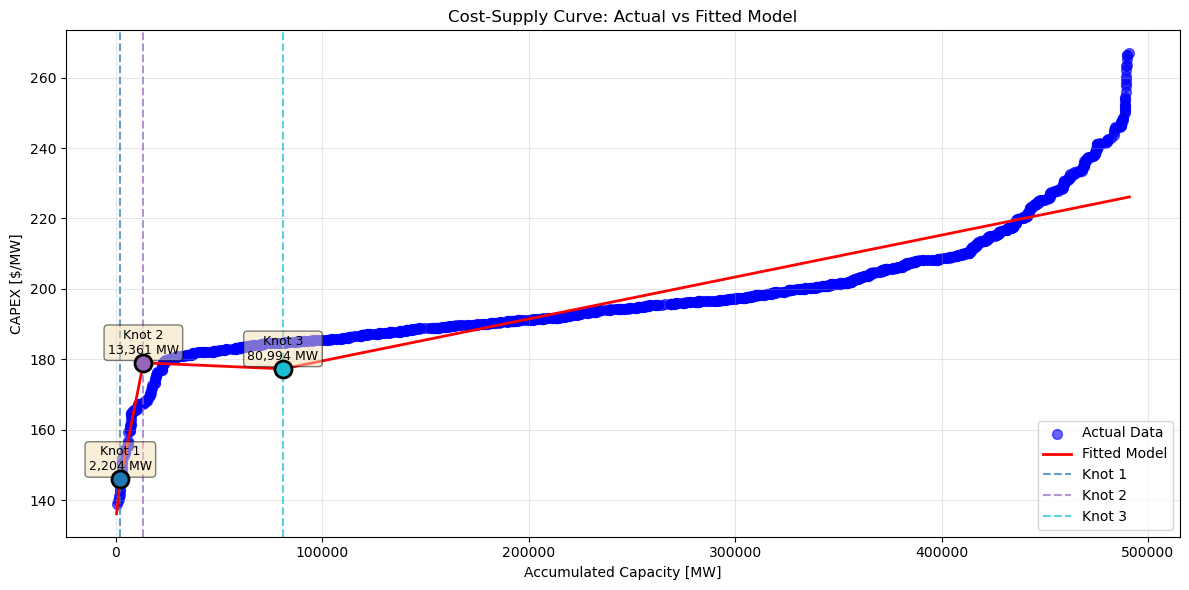

--- OPTIMIZED LINEAR COEFFICIENTS ---
  Intercept c1: 134.311999
  Knot 1: 2,204.16
  Knot 2: 13,361.29
  Knot 3: 80,994.22
  Slope m1: 0.00527681
  Slope m2: 0.00296895
  Slope m3: -0.00002571
  Slope m4: 0.00011899
-------------------------------------


In [353]:
popt, fn, knots, slopes, c1 = fit_piecewise_linear_given((capacity_fit), capex_fit, N=4, knot_method="log")    # 2=N-1 knots for every N bins)
plot_piecewise_fit_given((capacity_fit), capex_fit, fn, knots, slopes, c1, popt)

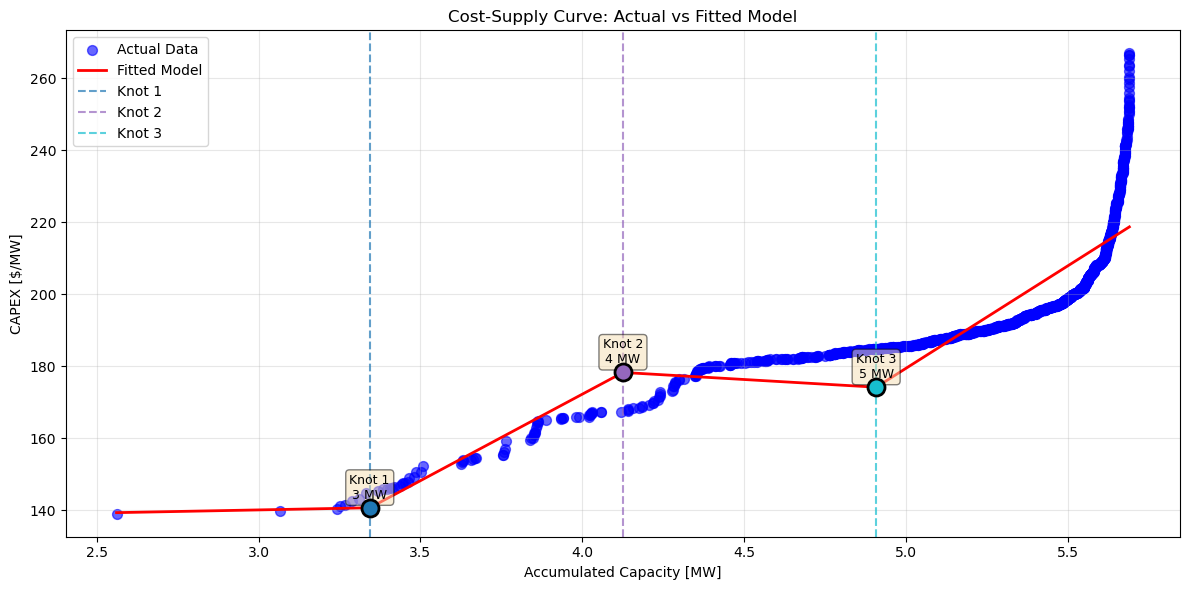

--- OPTIMIZED LINEAR COEFFICIENTS ---
  Intercept c1: 134.882321
  Knot 1: 3.34
  Knot 2: 4.13
  Knot 3: 4.91
  Slope m1: 1.72798362
  Slope m2: 48.02015419
  Slope m3: -5.22654701
  Slope m4: 56.88286899
-------------------------------------


In [354]:
popt, fn, knots, slopes, c1 = fit_piecewise_linear_given(np.log10(capacity_fit), capex_fit, N=4, knot_method="linear")    # 2=N-1 knots for every N bins)
plot_piecewise_fit_given(np.log10(capacity_fit), capex_fit, fn, knots, slopes, c1, popt)

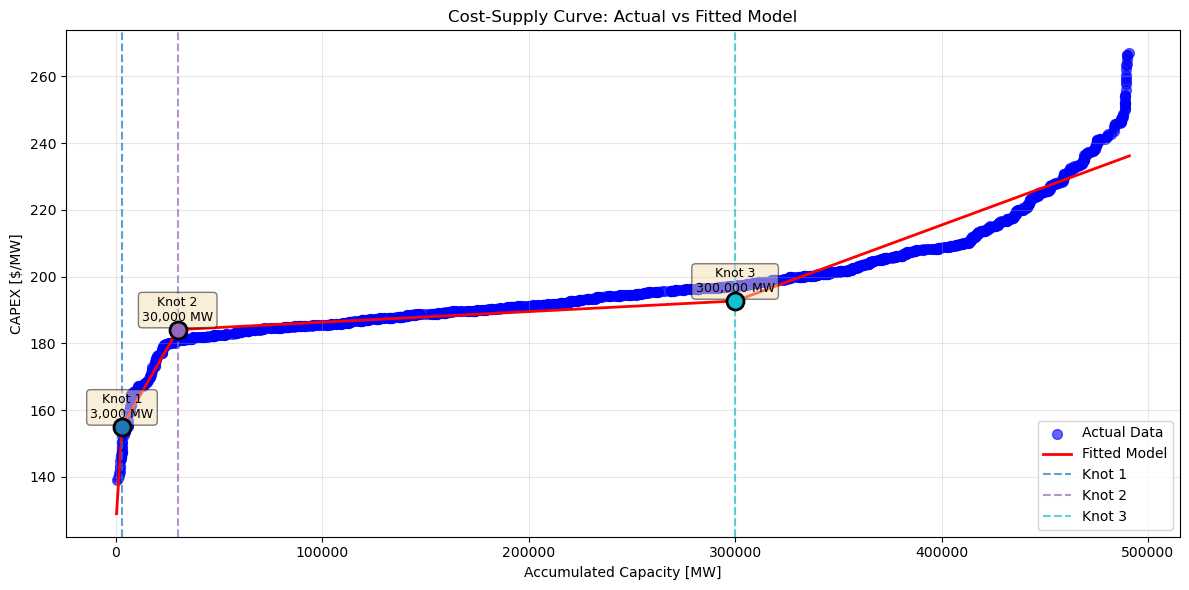

--- OPTIMIZED LINEAR COEFFICIENTS ---
  Intercept c1: 125.425460
  Knot 1: 3,000.00
  Knot 2: 30,000.00
  Knot 3: 300,000.00
  Slope m1: 0.00985348
  Slope m2: 0.00107944
  Slope m3: 0.00003173
  Slope m4: 0.00022755
-------------------------------------


In [355]:
popt, fn, knots, slopes, c1 = fit_piecewise_linear_given((capacity_fit), capex_fit, N=4, knot_method="log", knots=[3000,30000,300000])    # 2=N-1 knots for every N bins)
plot_piecewise_fit_given((capacity_fit), capex_fit, fn, knots, slopes, c1, popt)

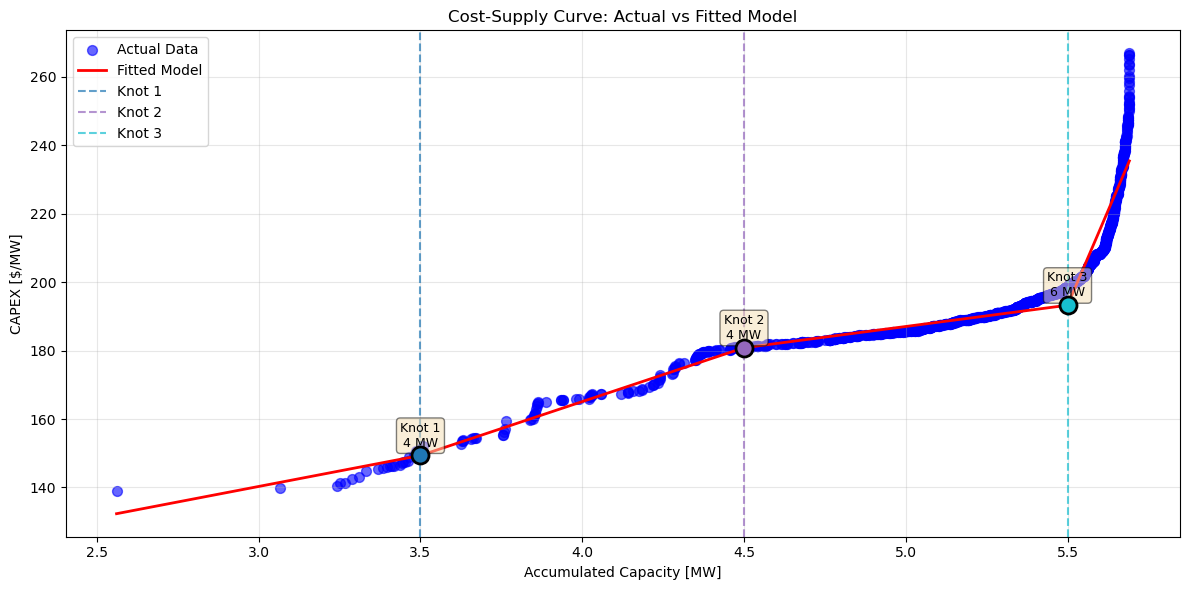

--- OPTIMIZED LINEAR COEFFICIENTS ---
  Intercept c1: 85.924741
  Knot 1: 3.50
  Knot 2: 4.50
  Knot 3: 5.50
  Slope m1: 18.12140424
  Slope m2: 31.48012566
  Slope m3: 12.42158234
  Slope m4: 220.70461048
-------------------------------------


In [356]:
popt, fn, knots, slopes, c1 = fit_piecewise_linear_given(np.log10(capacity_fit), capex_fit, N=4, knot_method="linear", knots=[3.5,4.5,5.5])    # 2=N-1 knots for every N bins)
plot_piecewise_fit_given(np.log10(capacity_fit), capex_fit, fn, knots, slopes, c1, popt)

# Testing Piecewise funtion based on N bins (linear formulation based directly on averaging intermediate knots)

In [357]:
def make_piecewise_knot_based(N, knots):
    """
    Factory function that returns a piecewise linear function with N segments
    and fixed (homogeneous) knots.
    
    Parameters:
      N : number of linear segments (bins)
      knots : list of N-1 knot positions (pre-calculated, fixed)
    
    The parameter vector is structured as:
      [m_1, m_2, ..., m_N,                <- N slopes
       c_1]                               <- 1 intercept (first segment only)
    Total: N + 1 parameters (knots are fixed, not fitted)
    """
    knots = np.array(knots)
    
    def piecewise_linear(x, *params):
        slopes = np.array(params[:N])      # N slopes
        c1 = params[N]                     # intercept of first segment

        y = np.zeros_like(x, dtype=float)

        # Precompute the y-value at each knot (continuity constraints)
        y_at_knots = np.zeros(N-1)
        y_at_knots[0] = slopes[0] * knots[0] + c1
        for i in range(1, N-1):
            y_at_knots[i] = slopes[i] * (knots[i] - knots[i-1]) + y_at_knots[i-1]

        # --- Segment 1: x < knot_1 ---
        mask = x < knots[0]
        y[mask] = slopes[0] * x[mask] + c1

        # --- Segments 2 to N-1: knot_{i-1} <= x < knot_i ---
        for i in range(1, N-1):
            mask = (x >= knots[i-1]) & (x < knots[i])
            y[mask] = slopes[i] * (x[mask] - knots[i-1]) + y_at_knots[i-1]

        # --- Segment N (last): x >= knot_{N-1} ---
        mask = x >= knots[-1]
        y[mask] = slopes[-1] * (x[mask] - knots[-1]) + y_at_knots[-1]

        return y

    piecewise_linear.__name__ = f"piecewise_linear_given_N{N}"
    return piecewise_linear

def fit_piecewise_linear_knot_based(
        x_data,
        y_data,
        N,
        knots=None,
        knot_method="log",
        ):
    """
    Fit a piecewise linear function with N segments by computing slopes
    directly from interpolated y-values at knot positions. Each segment is independent.

    Parameters
    ----------
    x_data, y_data   : array-like, the data to fit
    N                : int, number of segments
    knots            : list or None, fixed knot x-positions (N-1 values)
                       If None, generated automatically via knot_method
    knot_method      : {"log", "linear"}, used when knots=None
    window_fraction  : float, fraction of local x-range to average y over
                       at each knot (robustness against noise). Default 0.05

    Returns
    -------
    popt   : np.array of [slopes..., c1]
    fn     : callable piecewise linear function
    knots  : list of knot x-positions
    slopes : list of slopes per segment
    c1     : intercept of first segment
    """
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    # --- Sort data (required for reliable interpolation) ---
    sort_idx = np.argsort(x_data)
    x_data = x_data[sort_idx]
    y_data = y_data[sort_idx]

    # --------------------------------------------------
    # Generate knots automatically if not provided
    # --------------------------------------------------
    if knots is None:
        if knot_method == "log":
            log_min = np.log10(x_data.min())
            log_max = np.log10(x_data.max())
            range_log = (log_max - log_min) / N
            knots = list(10 ** np.array([
                log_min + (i + 1) * range_log for i in range(N - 1)
            ]))
        elif knot_method == "linear":
            x_min, x_max = x_data.min(), x_data.max()
            step = (x_max - x_min) / N
            knots = [x_min + (i + 1) * step for i in range(N - 1)]
        else:
            raise ValueError("knot_method must be 'log' or 'linear'")

    # --------------------------------------------------
    # Validate knots
    # --------------------------------------------------
    knots = list(knots)
    if len(knots) != N - 1:
        raise ValueError(f"Expected {N-1} knots for N={N} segments, got {len(knots)}.")
    if knots != sorted(knots):
        raise ValueError("Knots must be strictly increasing.")

    # --------------------------------------------------
    # Evaluate y at boundaries via interpolation
    # --------------------------------------------------
    x_boundaries = np.array([x_data.min()] + knots + [x_data.max()])
    y_boundaries = np.interp(x_boundaries, x_data, y_data)

    # --------------------------------------------------
    # Compute slopes analytically per segment
    # --------------------------------------------------
    slopes = []
    for i in range(N):
        dx = x_boundaries[i + 1] - x_boundaries[i]
        dy = y_boundaries[i + 1] - y_boundaries[i]
        slopes.append(dy / dx)

    # --------------------------------------------------
    # Compute intercept from first boundary point
    # --------------------------------------------------
    c1 = y_boundaries[0] - slopes[0] * x_boundaries[0]

    fn   = make_piecewise_linear_given(N, knots)
    popt = np.array(slopes + [c1])

    return popt, fn, knots, slopes, c1

def plot_piecewise_knot_based(x_data, y_data, fn, knots, slopes, c1, popt,
                       x_label="Accumulated Capacity [MW]",
                       y_label="CAPEX [$/MW]",
                       title="Cost-Supply Curve: Actual vs Fitted Model"):
    
    N = len(slopes)
    
    # --- Evaluate fitted curve and knot heights ---
    y_predicted = fn(x_data, *popt)
    y_at_knots  = [fn(np.array([k]), *popt)[0] for k in knots]

    # --- Colors for knots (cycles if N is large) ---
    knot_colors = plt.cm.tab10(np.linspace(0, 0.9, len(knots)))

    # --- Plot ---
    plt.figure(figsize=(12, 6))

    plt.scatter(x_data, y_data, color='blue', label='Actual Data', alpha=0.6, s=50)
    plt.plot(x_data, y_predicted, color='red', linewidth=2, label='Fitted Model')

    for i, (k, yk, color) in enumerate(zip(knots, y_at_knots, knot_colors)):
        plt.axvline(x=k, color=color, linestyle='--', linewidth=1.5, alpha=0.7,
                    label=f'Knot {i+1}')
        plt.scatter([k], [yk], color=[color], s=150, marker='o',
                    edgecolors='black', linewidth=2, zorder=5)
        plt.text(k, yk + 0.02 * (y_data.max() - y_data.min()),
                 f'Knot {i+1}\n{k:,.0f} MW',
                 ha='center', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Print summary ---
    print("--- OPTIMIZED LINEAR COEFFICIENTS ---")
    print(f"  Intercept c1: {c1:.6f}")
    for i, k in enumerate(knots):
        print(f"  Knot {i+1}: {k:,.2f}")
    for i, m in enumerate(slopes):
        print(f"  Slope m{i+1}: {m:.8f}")
    print("-------------------------------------")

In [358]:
def fit_piecewise_linear_knot_based(x_data, y_data, N, knots=None, knot_method="log"):

    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    sort_idx = np.argsort(x_data)
    x_data = x_data[sort_idx]
    y_data = y_data[sort_idx]

    if knots is None:
        if knot_method == "log":
            log_min = np.log10(x_data.min())
            log_max = np.log10(x_data.max())
            range_log = (log_max - log_min) / N
            knots = list(10 ** np.array([log_min + (i + 1) * range_log for i in range(N - 1)]))
        elif knot_method == "linear":
            x_min, x_max = x_data.min(), x_data.max()
            step = (x_max - x_min) / N
            knots = [x_min + (i + 1) * step for i in range(N - 1)]
        else:
            raise ValueError("knot_method must be 'log' or 'linear'")

    knots = list(knots)
    if len(knots) != N - 1:
        raise ValueError(f"Expected {N-1} knots for N={N} segments, got {len(knots)}.")
    if knots != sorted(knots):
        raise ValueError("Knots must be strictly increasing.")

    x_boundaries = np.array([x_data.min()] + knots + [x_data.max()])
    y_boundaries = np.interp(x_boundaries, x_data, y_data)

    slopes = [(y_boundaries[i+1] - y_boundaries[i]) / (x_boundaries[i+1] - x_boundaries[i])
              for i in range(N)]

    return x_boundaries, y_boundaries, knots, slopes


In [359]:
def plot_piecewise_knot_based(x_data, y_data, x_boundaries, y_boundaries, knots, slopes,
                               x_label="Accumulated Capacity [MW]",
                               y_label="CAPEX [$/MW]",
                               title="Cost-Supply Curve: Actual vs Fitted Model"):

    knot_colors = plt.cm.tab10(np.linspace(0, 0.9, len(knots)))

    plt.figure(figsize=(12, 6))
    plt.scatter(x_data, y_data, color='blue', label='Actual Data', alpha=0.6, s=50)
    plt.plot(x_boundaries, y_boundaries, color='red', linewidth=2, label='Fitted Model')

    for i, (k, yk, color) in enumerate(zip(knots, y_boundaries[1:-1], knot_colors)):
        plt.axvline(x=k, color=color, linestyle='--', linewidth=1.5, alpha=0.7, label=f'Knot {i+1}')
        plt.scatter([k], [yk], color=[color], s=150, marker='o', edgecolors='black', linewidth=2, zorder=5)
        plt.text(k, yk + 0.02 * (y_data.max() - y_data.min()),
                 f'Knot {i+1}\n{k:,.0f} MW',
                 ha='center', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("--- SEGMENT COEFFICIENTS ---")
    for i, m in enumerate(slopes):
        print(f"  Slope m{i+1}: {m:.8f}")
    for i, k in enumerate(knots):
        print(f"  Knot {i+1}: {k:,.2f} MW  →  y = {y_boundaries[i+1]:,.2f}")
    print("----------------------------")

In [360]:
def plot_piecewise_bin_averages(x_data, y_data, x_boundaries, y_boundaries, knots, slopes, scale=None,
                               x_label="Accumulated Capacity [MW]",
                               y_label="CAPEX [$/MW]",
                               title="Cost-Supply Curve: Data and Bin Averages"):
    knot_colors = plt.cm.tab10(np.linspace(0, 0.9, len(knots)))

    plt.figure(figsize=(12, 6))
    plt.scatter(x_data, y_data, color='blue', label='Actual Data', alpha=0.6, s=50)
    #plt.plot(x_boundaries, y_boundaries, color='red', linewidth=2, label='Fitted Model')

    # vertical lines at knots (keep bin separators)
    for i, (k, color) in enumerate(zip(knots, knot_colors)):
        plt.axvline(x=k, color=color, linestyle='--', linewidth=1.5, alpha=0.7, label=(f'Knot {i+1}'))

    # compute per-bin averages and annotate
    bin_avgs = []
    bin_centers = []
    yspan = y_data.max() - y_data.min() if (y_data.size and y_data.max() != y_data.min()) else 1.0
    for j in range(len(x_boundaries) - 1):
        left = x_boundaries[j]
        right = x_boundaries[j + 1]
        # inclusive on last bin
        if j < len(x_boundaries) - 2:
            mask = (x_data >= left) & (x_data < right)
        else:
            mask = (x_data >= left) & (x_data <= right)

        if np.any(mask):
            avg_y = np.nanmean(y_data[mask])
        else:
            avg_y = np.nan

        bin_avgs.append(avg_y)
        bin_centers.append((left + right) / 2.0)

    for j, (cx, avg) in enumerate(zip(bin_centers, bin_avgs)):
        if np.isnan(avg):
            continue
        plt.text(cx, avg + 0.04 * yspan,
                 f'Bin{j+1}: Avg CAPEX\n{avg:,.2f}',
                 ha='center', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

    
    # Draw horizontal average in each bin
    first = True

    for j, avg in enumerate(bin_avgs):

        if np.isnan(avg):
            continue

        left = x_boundaries[j]
        right = x_boundaries[j + 1]

        plt.plot(
            [left, right],
            [avg, avg],
            color='red',
            linewidth=3,
            label='Bin Average' if first else None
        )

        first = False
    
    # # Print knot lines and annotations
    # for i, (k, yk, color) in enumerate(zip(knots, y_boundaries[1:-1], knot_colors)):
    #     plt.scatter([k], [yk], color=[color], s=150, marker='o', edgecolors='black', linewidth=2, zorder=5)
    #     plt.text(k, yk + 0.02 * (y_data.max() - y_data.min()),
    #              f'Bin {i+1}: Max capacity\n{k:,.0f} MW',
    #              ha='center', fontsize=9,
    #              bbox=dict(boxstyle='round', facecolor='green', alpha=0.5))

    if scale == "log10":
        
        plt.xlabel(f"({scale} {x_label})")
    else:
        plt.xlabel(f"{x_label}")
    plt.ylabel(f"{y_label}")
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # print summary info
    print("--- SEGMENT COEFFICIENTS ---")
    for i, m in enumerate(slopes):
        print(f"  Slope m{i+1}: {m:.8f}")
    for i, (left, right, avg) in enumerate(zip(x_boundaries[:-1], x_boundaries[1:], bin_avgs)):
        avg_str = f"{avg:,.2f}" if not np.isnan(avg) else "n/a"
        print(f"  Bin {i+1}: [{left:,.0f}, {right:,.0f}) MW  →  avg y = {avg_str}")
    print("----------------------------")

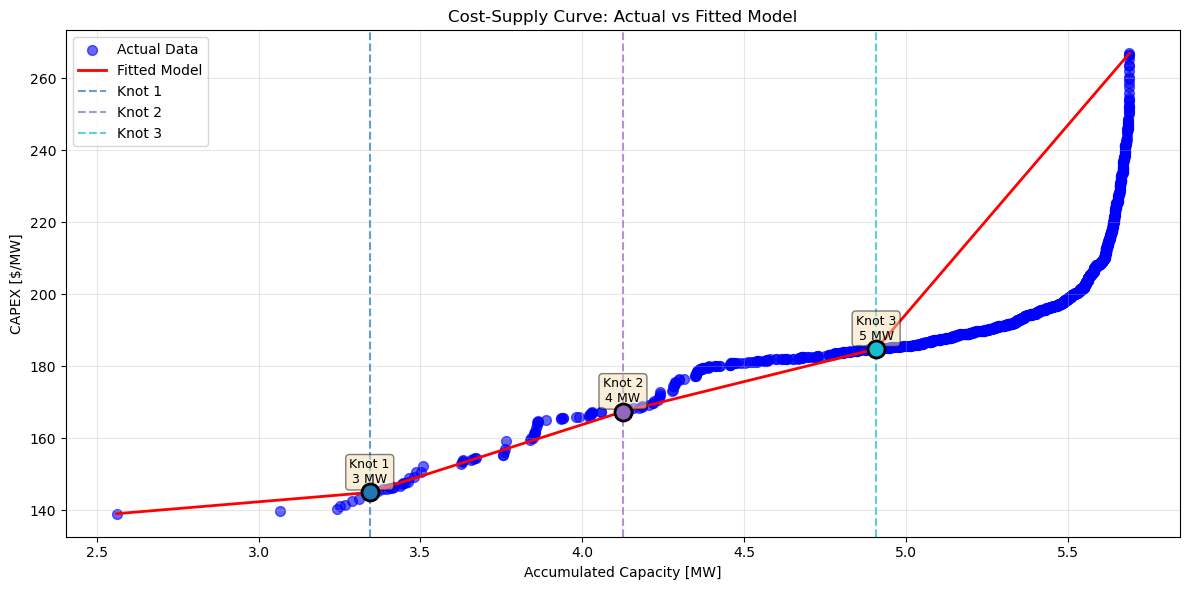

--- SEGMENT COEFFICIENTS ---
  Slope m1: 7.53985379
  Slope m2: 28.69826810
  Slope m3: 22.23001992
  Slope m4: 104.89386231
  Knot 1: 3.34 MW  →  y = 144.91
  Knot 2: 4.13 MW  →  y = 167.37
  Knot 3: 4.91 MW  →  y = 184.77
----------------------------


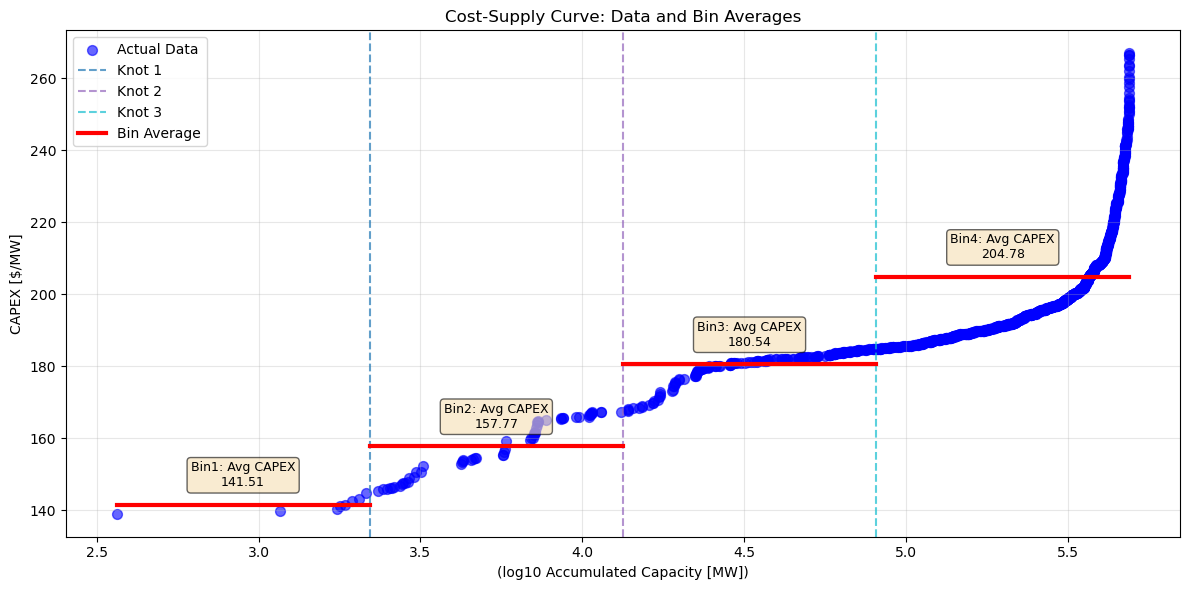

--- SEGMENT COEFFICIENTS ---
  Slope m1: 7.53985379
  Slope m2: 28.69826810
  Slope m3: 22.23001992
  Slope m4: 104.89386231
  Bin 1: [3, 3) MW  →  avg y = 141.51
  Bin 2: [3, 4) MW  →  avg y = 157.77
  Bin 3: [4, 5) MW  →  avg y = 180.54
  Bin 4: [5, 6) MW  →  avg y = 204.78
----------------------------


In [361]:
x_boundaries, y_boundaries, knots, slopes = fit_piecewise_linear_knot_based(np.log10(capacity_fit), capex_fit, N=4, knot_method="linear")
plot_piecewise_knot_based(np.log10(capacity_fit), capex_fit, x_boundaries, y_boundaries, knots, slopes)
plot_piecewise_bin_averages(np.log10(capacity_fit), capex_fit, x_boundaries, y_boundaries, knots, slopes,scale="log10")

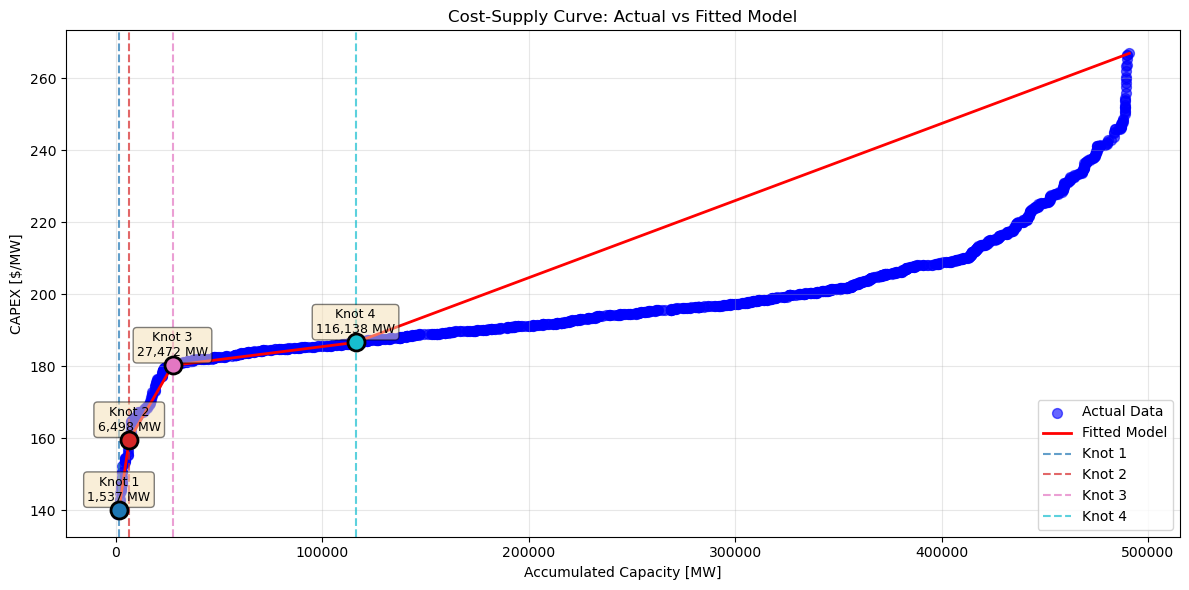

--- SEGMENT COEFFICIENTS ---
  Slope m1: 0.00091013
  Slope m2: 0.00391400
  Slope m3: 0.00098621
  Slope m4: 0.00007220
  Slope m5: 0.00021416
  Knot 1: 1,537.17 MW  →  y = 140.08
  Knot 2: 6,498.39 MW  →  y = 159.50
  Knot 3: 27,472.02 MW  →  y = 180.18
  Knot 4: 116,138.23 MW  →  y = 186.59
----------------------------


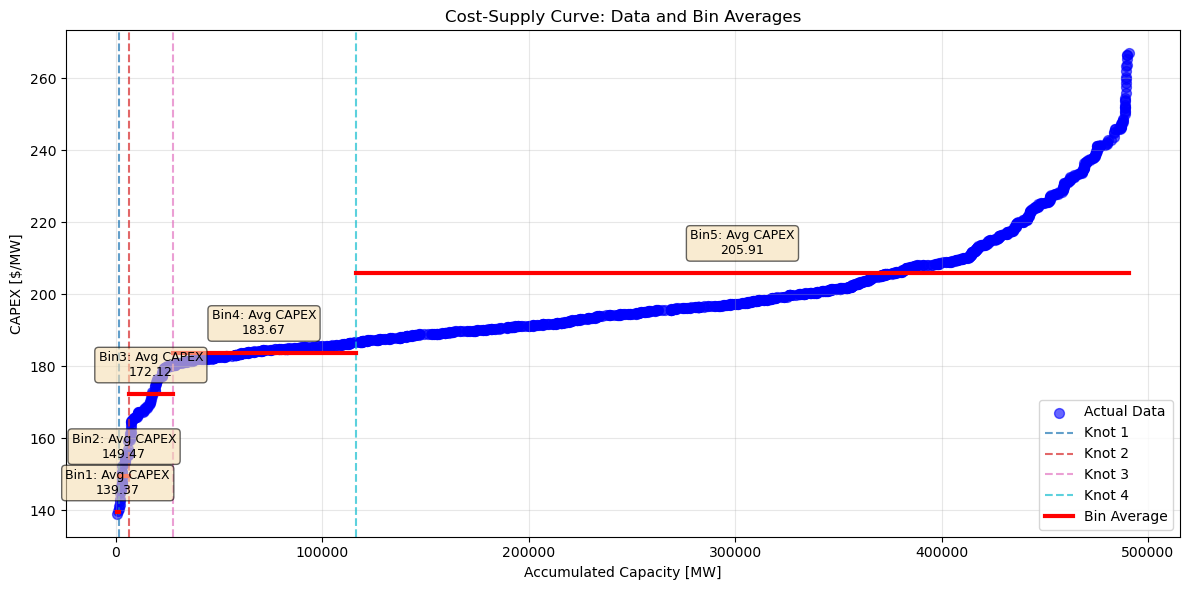

--- SEGMENT COEFFICIENTS ---
  Slope m1: 0.00091013
  Slope m2: 0.00391400
  Slope m3: 0.00098621
  Slope m4: 0.00007220
  Slope m5: 0.00021416
  Bin 1: [364, 1,537) MW  →  avg y = 139.37
  Bin 2: [1,537, 6,498) MW  →  avg y = 149.47
  Bin 3: [6,498, 27,472) MW  →  avg y = 172.12
  Bin 4: [27,472, 116,138) MW  →  avg y = 183.67
  Bin 5: [116,138, 490,975) MW  →  avg y = 205.91
----------------------------


In [376]:
x_boundaries, y_boundaries, knots, slopes = fit_piecewise_linear_knot_based((capacity_fit), capex_fit, N=5, knot_method="log")
plot_piecewise_knot_based((capacity_fit), capex_fit, x_boundaries, y_boundaries, knots, slopes)
plot_piecewise_bin_averages((capacity_fit), capex_fit, x_boundaries, y_boundaries, knots, slopes)

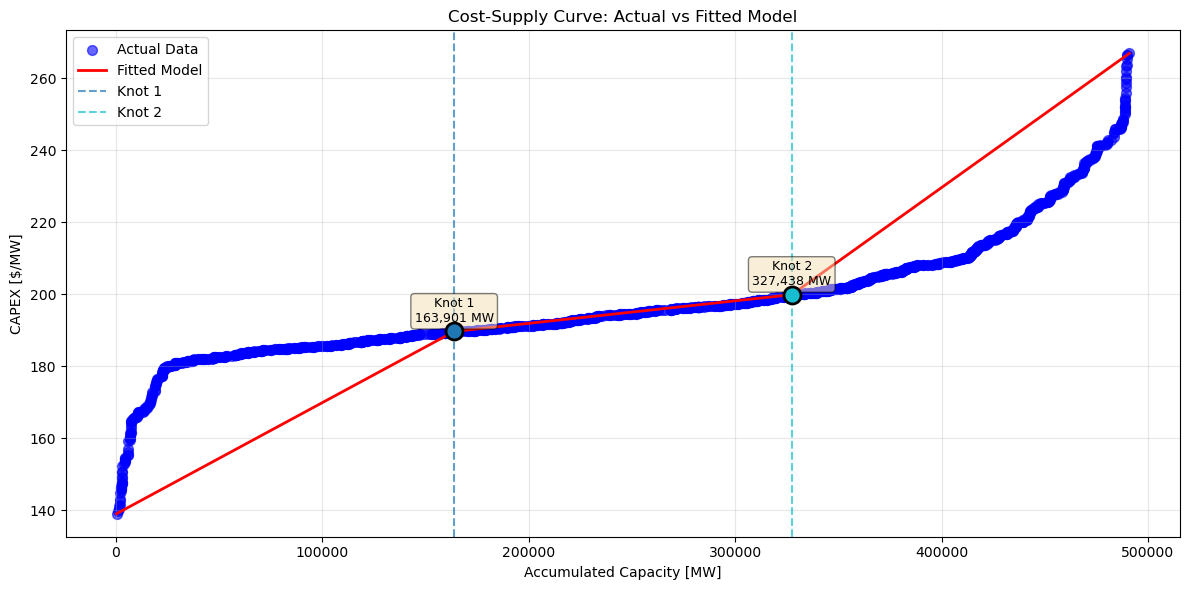

--- SEGMENT COEFFICIENTS ---
  Slope m1: 0.00030944
  Slope m2: 0.00006255
  Slope m3: 0.00040977
  Knot 1: 163,900.88 MW  →  y = 189.62
  Knot 2: 327,438.16 MW  →  y = 199.85
----------------------------


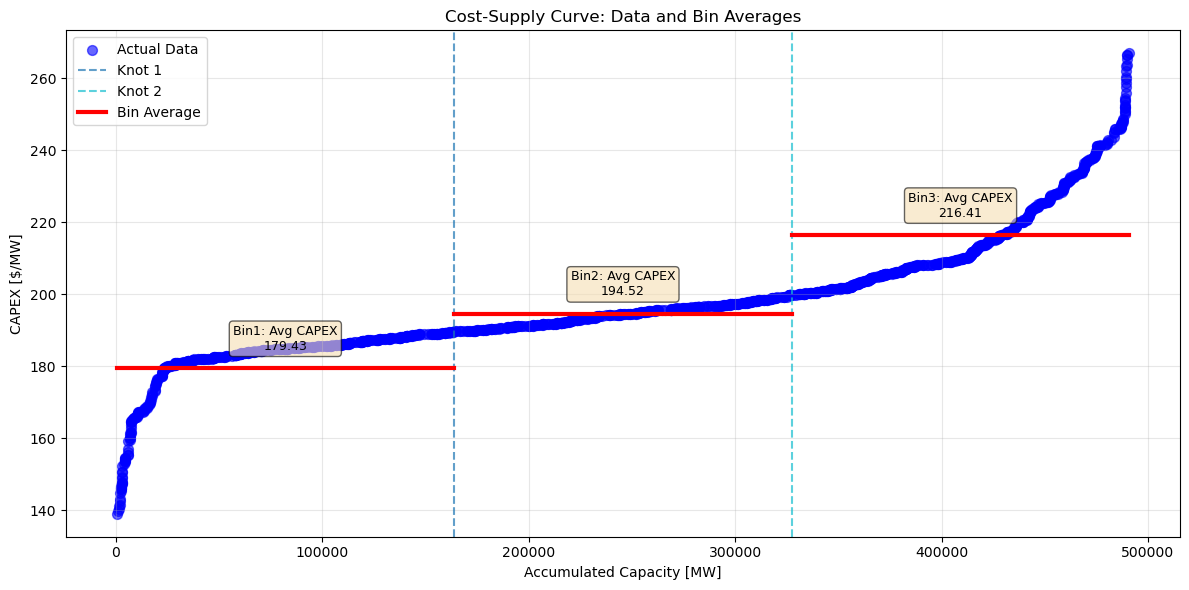

--- SEGMENT COEFFICIENTS ---
  Slope m1: 0.00030944
  Slope m2: 0.00006255
  Slope m3: 0.00040977
  Bin 1: [364, 163,901) MW  →  avg y = 179.43
  Bin 2: [163,901, 327,438) MW  →  avg y = 194.52
  Bin 3: [327,438, 490,975) MW  →  avg y = 216.41
----------------------------


In [ ]:
x_boundaries, y_boundaries, knots, slopes = fit_piecewise_linear_knot_based((capacity_fit), capex_fit, N=3, knot_method="linear")
plot_piecewise_knot_based((capacity_fit), capex_fit, x_boundaries, y_boundaries, knots, slopes)
plot_piecewise_bin_averages((capacity_fit), capex_fit, x_boundaries, y_boundaries, knots, slopes)